In [50]:
import os
import torch
import numpy as np
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score

from models.youverse.model_insightface import load_insightface_ir50_model
from datasets.face_pair_dataset import FacePairDataset
from datasets.face_verification_dataset import FaceVerificationDataset


In [61]:
def get_embedding(model, image):
    with torch.no_grad():
        embedding = model(image)
    return embedding

model = load_insightface_ir50_model("models_bin/backbone_ir50_ms1m_epoch120.pth", device="cpu")

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = FaceVerificationDataset(
    pairs_file='datasets/clean_eval_pairs.txt',
    image_dir='AdvCelebA/images',
    transform=transform
)

val_loader = DataLoader(dataset, batch_size=32, shuffle=False)

In [65]:
dataset = FacePairDataset("AdvLFW/images")
val_loader = DataLoader(dataset, batch_size=32, shuffle=False)

In [69]:
all_labels = []
all_scores = []

model.eval()

for batch in val_loader:
    img1 = batch['image1']
    img2 = batch['image2']
    labels = batch['label']

    emb1 = get_embedding(model, img1)
    emb2 = get_embedding(model, img2)

    sim_scores = model.cosine_similarity(emb1, emb2) 

    all_scores.extend(sim_scores.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

    if len(all_scores) >= 1000:
        break

In [70]:
len(all_labels), sum(all_labels)

(1000, np.int64(500))

In [74]:
threshold = 0.2626

preds = [1 if score > threshold else 0 for score in all_scores]

acc = accuracy_score(all_labels, preds)
roc_auc = roc_auc_score(all_labels, all_scores)

print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.9750
ROC AUC: 0.9852


In [73]:
thresholds = np.linspace(0, 1, 100)
accuracies = [accuracy_score(all_labels, [1 if s > t else 0 for s in all_scores]) for t in thresholds]

best_threshold = thresholds[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"Best threshold: {best_threshold:.4f}, Best accuracy: {best_accuracy:.4f}")

Best threshold: 0.2626, Best accuracy: 0.9750


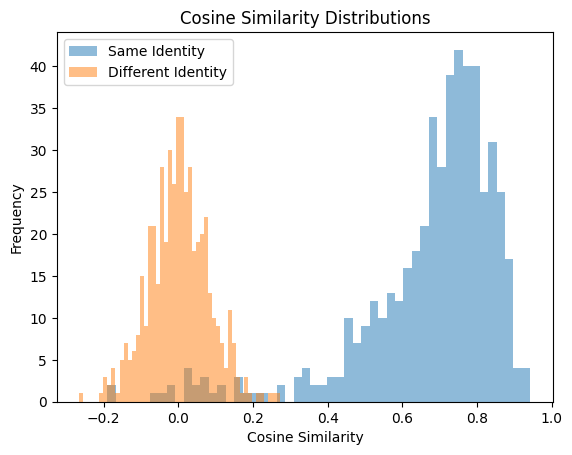

In [75]:
import matplotlib.pyplot as plt

import numpy as np
all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

plt.hist(all_scores[all_labels == 1], bins=50, alpha=0.5, label='Same Identity')
plt.hist(all_scores[all_labels == 0], bins=50, alpha=0.5, label='Different Identity')
plt.legend()
plt.title('Cosine Similarity Distributions')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()